In [2]:
%matplotlib inline
import sys
from pathlib import Path
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from MonteCarlo.MonteCarlo import sample_from_epsilon_ball, monte_carlo_sample_cluster

# parent directory to path for imports
sys.path.append(str(Path.cwd().parent))

#  import utility functions from existing modules
from train_cvae import load_data
from ae_utils import _encode, _decode

In [3]:
root = Path.cwd().parent
dataset_type = 'scenairo'

if dataset_type == 'mnist':
    checkpoint_path = root / 'ASAB/runs/0904_mnist/vae_1.pth'
    latent_dim = 12
    data_csv = None

if dataset_type == 'scenairo':
    checkpoint_path = root / 'ASAB/runs/scenairo2004/vae_1.pth'
    latent_dim = 32
    data_csv = None

data = load_data(
    data_csv=data_csv,
    dataset=dataset_type,
    single_class=None,
    data_root=root / 'ASAB/DATA/ScenAIro'
)

X_train_tensor = data['X_train_tensor']
y_train = data['y_train']
input_dim = data['input_dim']
num_classes = data['class_size']
image_shape = data['image_shape']


Class mapping: {'norunway': 0, 'runway': 1}


In [4]:
target_class = 3 if dataset_type == 'mnist' else 0
latent_vectors = _encode(target_class,
                        num_classes,
                        input_dim,
                        latent_dim,
                        checkpoint_path,
                        dataset_type,
                        X_train_tensor,
                        y_train,
                        image_shape=image_shape)

print(latent_vectors)


tensor([[ 0.7318,  0.3298,  0.0855,  ...,  0.6509, -0.8366, -0.3317],
        [ 0.6367,  0.2007, -0.0300,  ...,  0.1013, -0.5710, -0.4051],
        [-0.3213,  1.0313, -0.4666,  ..., -0.8613, -0.3586, -0.2588],
        ...,
        [ 0.0185,  0.0115, -0.0271,  ...,  0.3348,  0.1529,  0.0580],
        [ 0.1417,  1.4916, -0.0219,  ...,  0.4110, -0.8631, -0.4997],
        [-0.1034,  0.6477,  0.0928,  ...,  0.8276,  0.8346, -0.1729]])


In [5]:
class_mask = y_train == target_class
X_train_class = X_train_tensor[class_mask]

latent_vectors = _encode(target_class,
                        num_classes,
                        input_dim,
                        latent_dim,
                        checkpoint_path,
                        dataset_type,
                        X_train_tensor,
                        y_train,
                        image_shape=image_shape)

n = min(5, len(latent_vectors))
fig, axes = plt.subplots(2, n, figsize=(n*2, 4))

for i in range(n):
    idx = torch.randint(len(latent_vectors), (1,)).item()
    orig = X_train_class[idx]

    reconstructed = _decode(
        latent_vectors[idx:idx+1],
        target_class,
        num_classes,
        input_dim,
        latent_dim,
        checkpoint_path,
        dataset_type,
        image_shape=image_shape
    )

    if dataset_type == 'mnist':
        axes[0, i].imshow(orig.numpy().reshape(28, 28), cmap='gray')
        axes[1, i].imshow(reconstructed[0].reshape(28, 28), cmap='gray')
    else:
        axes[0, i].imshow(orig.permute(1, 2, 0).numpy())
        axes[1, i].imshow(reconstructed[0].permute(1, 2, 0).detach().numpy())

    axes[0, i].set_title(f'Original {i}')
    axes[1, i].set_title(f'Reconstructed {i}')
    axes[0, i].axis('off')
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('reconstruction_preview.png', dpi=150)
plt.show()


/tmp/ipykernel_53200/2038273097.py:46: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [6]:
##################################
#### Monte-Carlo Cluster Sampling
##################################
class_mask = y_train == 1
X_train_class_0 = X_train_tensor[class_mask]

# encode all the training data for class 0
latent_vectors_0 = _encode(1,
                        num_classes,
                        input_dim,
                        latent_dim,
                        checkpoint_path,
                        dataset_type,
                        X_train_tensor,
                        y_train,
                        image_shape=image_shape)

# calculate the centroid and the max radius per class in the latent space
center = latent_vectors_0.mean(axis=0) # center dim is 32,
radius = np.linalg.norm(latent_vectors_0 - center, axis=1).max()

epsilon = 0

# generate random direction, repeatable for a seed
rng = np.random.default_rng(42)
directions = rng.normal(size=(1000, 32)) # 1000 samples with 32 latent dim columns
# normalize all directions to length 1
directions /= np.linalg.norm(directions, axis=1, keepdims=True)


# random distances inside the ball
r = rng.random(1000) ** (1 / 32)

# sample
sampled_points = center + directions * (r[:, None] * epsilon * radius)


/tmp/ipykernel_53200/2754201298.py:35: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  sampled_points = center + directions * (r[:, None] * epsilon * radius)


In [8]:
class_mask = y_train == 1
X_train_class_0 = X_train_tensor[class_mask]

# encode all the training data for class 0
latent_vectors_0 = _encode(1,
                        num_classes,
                        input_dim,
                        latent_dim,
                        checkpoint_path,
                        dataset_type,
                        X_train_tensor,
                        y_train,
                        image_shape=image_shape)

# calculate the centroid and the max radius per class in the latent space
center = latent_vectors_0.mean(axis=0) # center dim is 32,
radius = np.linalg.norm(latent_vectors_0 - center, axis=1).max()

sampled_points_ = sample_from_epsilon_ball(center, radius, 10)

target_class=1 -> runway


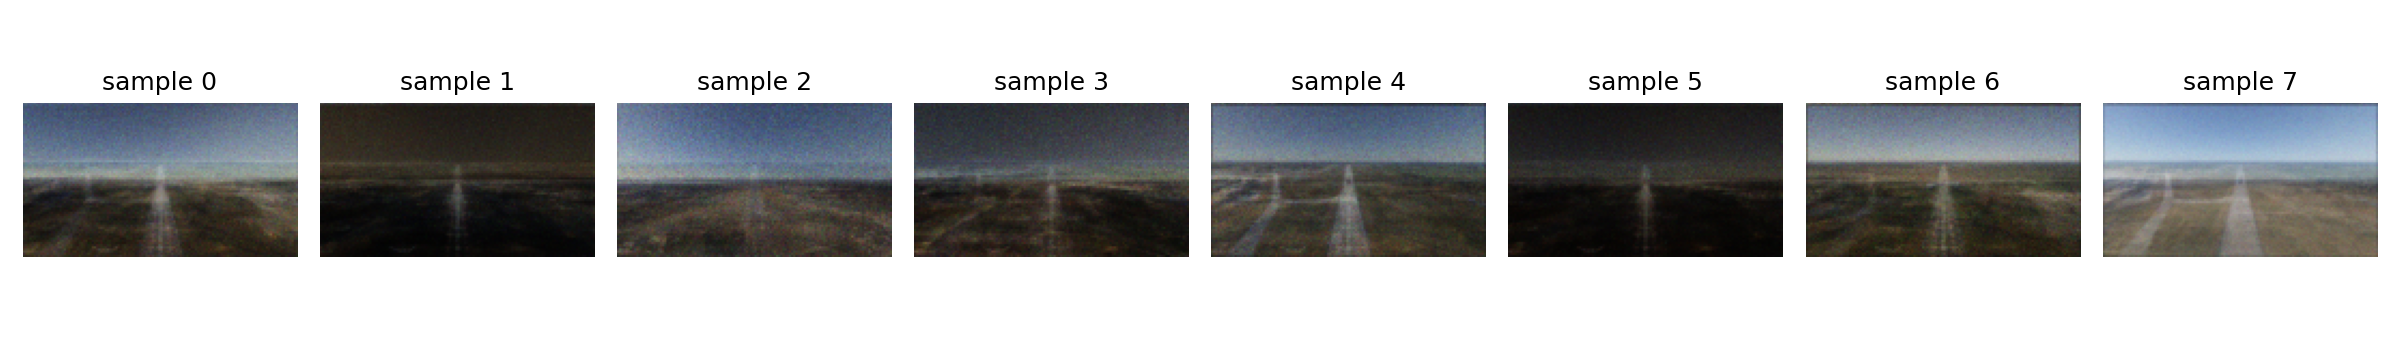

In [9]:
##################################
#### Decode a few MC samples
##################################
target_class = 1
M_show = 8
from IPython.display import Image, display

class_to_idx = data.get('class_to_idx', None)
if class_to_idx is not None:
    idx_to_class = {v: k for k, v in class_to_idx.items()}
    print(f"target_class={target_class} -> {idx_to_class[target_class]}")
else:
    print(f"target_class={target_class}")

points = sampled_points_[:M_show]
if not torch.is_tensor(points):
    points = torch.tensor(points, dtype=torch.float32)
else:
    points = points.detach().float()

decoded = _decode(
    points,
    target_class,
    num_classes,
    input_dim,
    latent_dim,
    checkpoint_path,
    dataset_type,
    image_shape=image_shape,
)

fig, axes = plt.subplots(1, M_show, figsize=(2*M_show, 2.4))
for i, ax in enumerate(axes):
    img = decoded[i].detach().cpu()
    if dataset_type == 'mnist':
        ax.imshow(img.reshape(28, 28), cmap='gray')
    else:
        ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(f"sample {i}")
    ax.axis('off')

plt.tight_layout()
out = Path('monte_carlo_decoded_preview.png')
plt.savefig(out, dpi=150)
plt.close(fig)
display(Image(filename=str(out)))


In [11]:
print(radius)

6.6924114
